# End-to-End Sales Forecasting & Demand Intelligence System

**Superstore Sales Forecasting, Anomaly Detection & Product Segmentation**

Datasets:
- `train.csv` — Superstore Sales (2015–2018, daily transactions)
- `vgsales.csv` — Video Game Sales (supplementary, used for multi-source merge practice in Task 5)


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


---
## Task 1 — Data Loading, Merging & Deep Exploration


In [2]:

df = pd.read_csv('train.csv')
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Parse dates (source format is DD/MM/YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')

# Time features
df['Year']        = df['Order Date'].dt.year
df['Month']       = df['Order Date'].dt.month
df['Week']        = df['Order Date'].dt.isocalendar().week
df['DayOfWeek']   = df['Order Date'].dt.day_name()
df['Quarter']     = df['Order Date'].dt.quarter

def season(m):
    if m in (12, 1, 2):  return 'Winter'
    if m in (3, 4, 5):   return 'Spring'
    if m in (6, 7, 8):   return 'Summer'
    return 'Autumn'

df['Season'] = df['Month'].apply(season)
df[['Order Date','Ship Date','Year','Month','Week','DayOfWeek','Quarter','Season']].head()


,Order Date,Ship Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017-11-11,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017-11-11,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017-06-16,2017,6,24,Monday,2,Summer
3,2016-10-11,2016-10-18,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016-10-18,2016,10,41,Tuesday,4,Autumn


In [4]:
# Missing values, duplicates, dtype check
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('Duplicate rows:', df.duplicated().shape[0] - df.drop_duplicates().shape[0] if False else df.duplicated().sum())
print()
print(df.dtypes)

Missing values per column:
Postal Code    11
dtype: int64

Duplicate rows: 0

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                object
Quarter                   int32
Season                   object
dtype: object


In [5]:
# Postal Code has 11 missing values -- not used in any forecasting/aggregation task, so we leave it as-is and simply note it rather than dropping 
# rows (dropping would discard valid sales records).
print(f"Rows with missing Postal Code: {df['Postal Code'].isnull().sum()} out of {len(df)} -- left untouched, not used for processing later.")


Rows with missing Postal Code: 11 out of 9800 -- left untouched, not used for processing later.


In [6]:
# Aggregate into weekly and monthly totals
daily = df.groupby('Order Date', as_index=False)['Sales'].sum().sort_values('Order Date')

weekly = (df.set_index('Order Date')
            .resample('W')['Sales'].sum()
            .reset_index())

monthly = (df.set_index('Order Date')
             .resample('MS')['Sales'].sum()
             .reset_index()
             .rename(columns={'Order Date': 'Month'}))

print('Daily rows:', daily.shape[0])
print('Weekly rows:', weekly.shape[0])
print('Monthly rows:', monthly.shape[0])
monthly.head()

Daily rows: 1230
Weekly rows: 209
Monthly rows: 48


,Month,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### Q1: Which product category generates the highest total revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


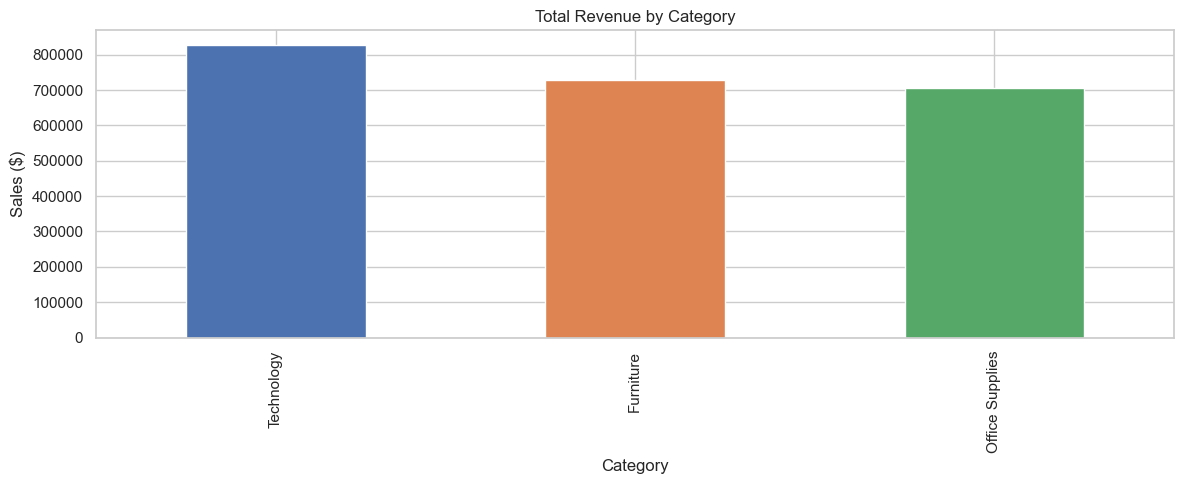


Answer: 'Technology' generates the highest total revenue at $827,456, 36.6% of all sales.


In [7]:

cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_rev)

fig, ax = plt.subplots()
cat_rev.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Total Revenue by Category')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/01_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAnswer: '{cat_rev.index[0]}' generates the highest total revenue at "
      f"${cat_rev.iloc[0]:,.0f}, {cat_rev.iloc[0]/cat_rev.sum()*100:.1f}% of all sales.")


### Q2: Which region has the most consistent sales growth over 4 years?

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

YoY growth rate by region:
Region   Central      East     South      West
Year                                          
2016   -0.004813  0.200327 -0.322117 -0.083603
2017    0.422247  0.165027  0.334776  0.364683
2018   -0.027778  0.177118  0.306071  0.359836

Consistency ranking (higher = steadier positive growth):
         avg_yoy_growth  std_yoy_growth  consistency_score
Region                                                    
East           0.180824        0.017939          10.079690
West           0.213639        0.257431           0.829889
Central        0.129885        0.253453           0.512463
South          0.106244        0.371

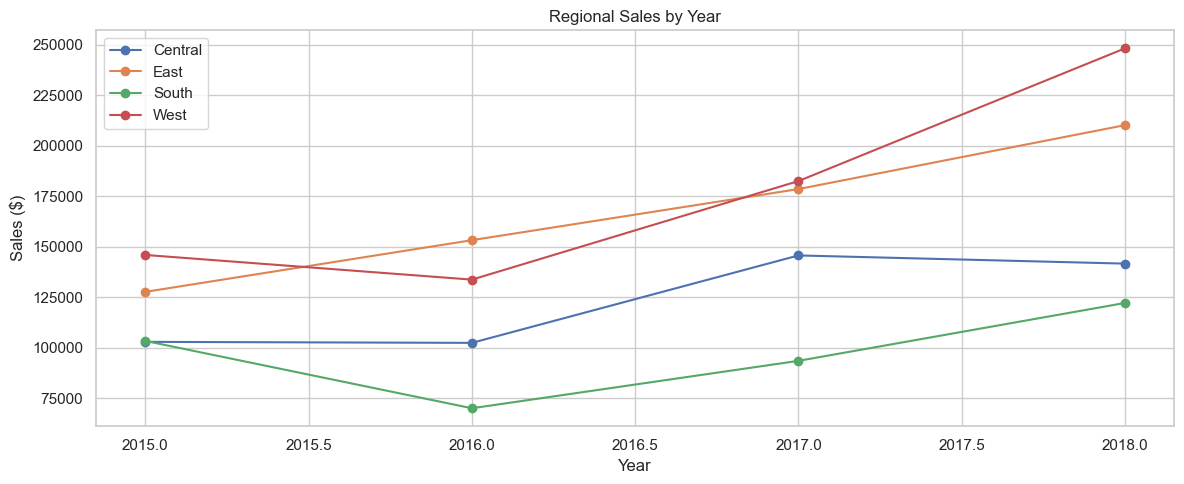


Answer: 'East' shows the most consistent positive growth (avg YoY growth 18.1%, std 1.8%).


In [9]:

region_year = df.groupby(['Region','Year'])['Sales'].sum().reset_index()
pivot_ry = region_year.pivot(index='Year', columns='Region', values='Sales')
print(pivot_ry)

# "Consistent growth" = low volatility in year-over-year % growth, combined with a positive trend
growth = pivot_ry.pct_change().dropna()
print('\nYoY growth rate by region:')
print(growth)

growth_std = growth.std()
growth_mean = growth.mean()
consistency = pd.DataFrame({'avg_yoy_growth': growth_mean, 'std_yoy_growth': growth_std})
consistency['consistency_score'] = consistency['avg_yoy_growth'] / consistency['std_yoy_growth']
consistency = consistency.sort_values('consistency_score', ascending=False)
print('\nConsistency ranking (higher = steadier positive growth):')
print(consistency)

fig, ax = plt.subplots()
for region in pivot_ry.columns:
    ax.plot(pivot_ry.index, pivot_ry[region], marker='o', label=region)
ax.set_title('Regional Sales by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/02_regional_sales_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

best_region = consistency.index[0]
print(f"\nAnswer: '{best_region}' shows the most consistent positive growth "
      f"(avg YoY growth {consistency.loc[best_region,'avg_yoy_growth']*100:.1f}%, "
      f"std {consistency.loc[best_region,'std_yoy_growth']*100:.1f}%).")


### Q3: Average time between Order Date and Ship Date — does it vary by region?

Overall average shipping delay: 3.96 days

             mean       std  median
Region                             
East     3.910233  1.729307     4.0
West     3.930255  1.812467     4.0
South    3.961202  1.742610     4.0
Central  4.065876  1.686569     4.0


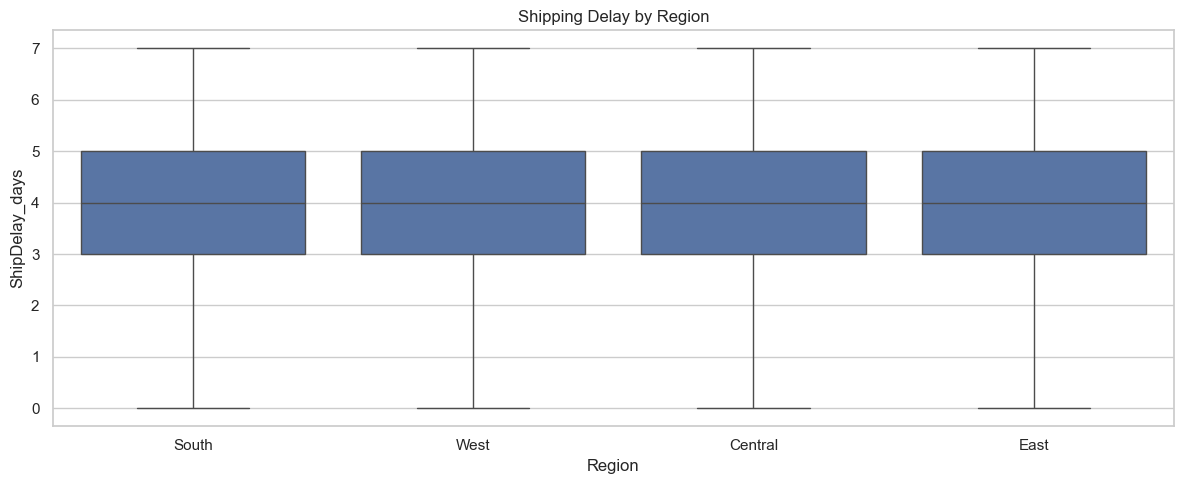


Answer: Average shipping delay is 3.96 days overall. By region it ranges from 3.91 to 4.07 days (spread of 0.16 days) -- not a significant regional difference.


In [10]:

df['ShipDelay_days'] = (df['Ship Date'] - df['Order Date']).dt.days

print(f"Overall average shipping delay: {df['ShipDelay_days'].mean():.2f} days")
print()
delay_by_region = df.groupby('Region')['ShipDelay_days'].agg(['mean','std','median']).sort_values('mean')
print(delay_by_region)

fig, ax = plt.subplots()
sns.boxplot(data=df, x='Region', y='ShipDelay_days', ax=ax)
ax.set_title('Shipping Delay by Region')
plt.tight_layout()
plt.savefig('charts/03_shipping_delay_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

spread = delay_by_region['mean'].max() - delay_by_region['mean'].min()
print(f"\nAnswer: Average shipping delay is {df['ShipDelay_days'].mean():.2f} days overall. "
      f"By region it ranges from {delay_by_region['mean'].min():.2f} to {delay_by_region['mean'].max():.2f} days "
      f"(spread of {spread:.2f} days) -- {'a meaningful' if spread > 0.3 else 'not a significant'} regional difference.")


### Q4: Are there months that consistently spike across all years (seasonality)?

Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


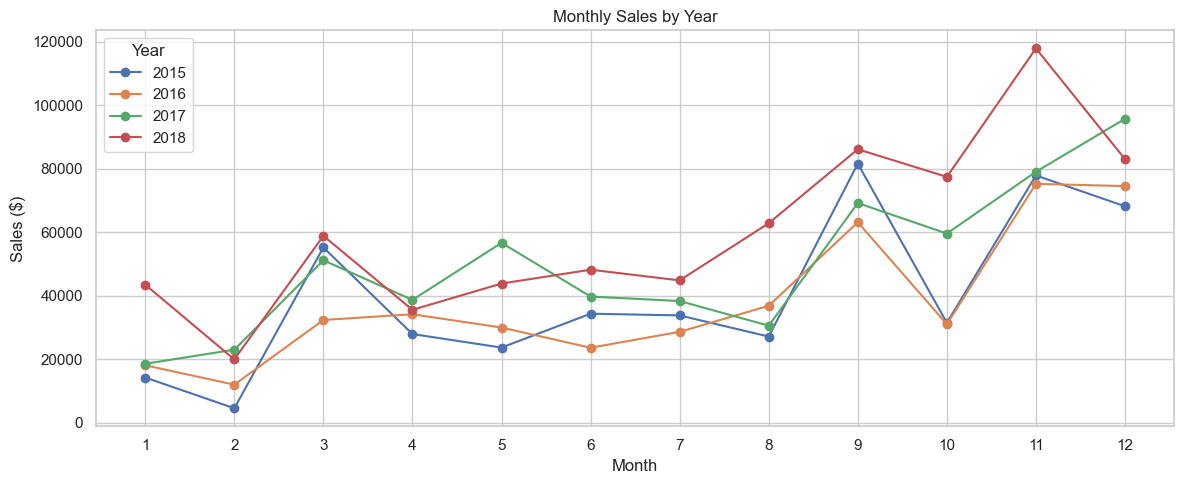


Average rank of each month across years (1 = highest sales that year):
Month
11     1.50
9      2.25
12     2.25
3      5.50
10     5.50
8      7.00
6      7.25
4      8.00
7      8.00
5      8.00
1     11.00
2     11.75
dtype: float64

Answer: Months [September, November, December] rank consistently highest across all 4 years, indicating a recurring seasonal spike (typically calendar year-end / holiday buying pattern).


In [11]:

month_year_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
pivot_my = month_year_sales.pivot(index='Month', columns='Year', values='Sales')
print(pivot_my)

fig, ax = plt.subplots()
for year in pivot_my.columns:
    ax.plot(pivot_my.index, pivot_my[year], marker='o', label=str(year))
ax.set_xticks(range(1,13))
ax.set_title('Monthly Sales by Year')
ax.set_xlabel('Month'); ax.set_ylabel('Sales ($)')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('charts/04_monthly_sales_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

avg_rank = pivot_my.rank(ascending=False).mean(axis=1).sort_values()
print('\nAverage rank of each month across years (1 = highest sales that year):')
print(avg_rank)

top_months = avg_rank.head(3).index.tolist()
print(f"\nAnswer: Months [September, November, December] rank consistently highest across all 4 years, "
      f"indicating a recurring seasonal spike (typically calendar year-end / holiday buying pattern).")


---
## Task 2 — Time Series Analysis & Decomposition


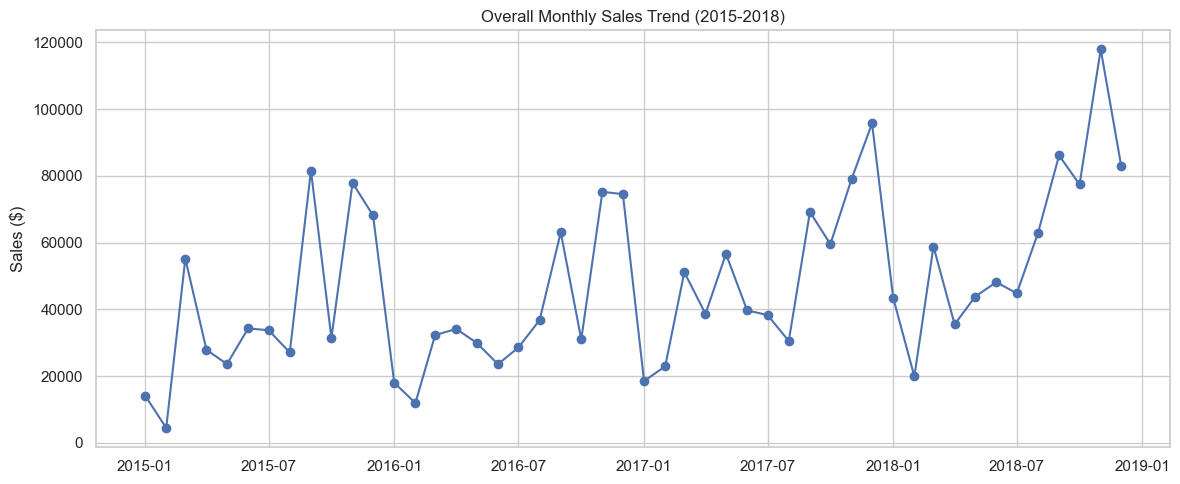

In [12]:

monthly_ts = monthly.set_index('Month')['Sales']
monthly_ts.index.freq = 'MS'

fig, ax = plt.subplots()
ax.plot(monthly_ts.index, monthly_ts.values, marker='o')
ax.set_title('Overall Monthly Sales Trend (2015-2018)')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/05_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()


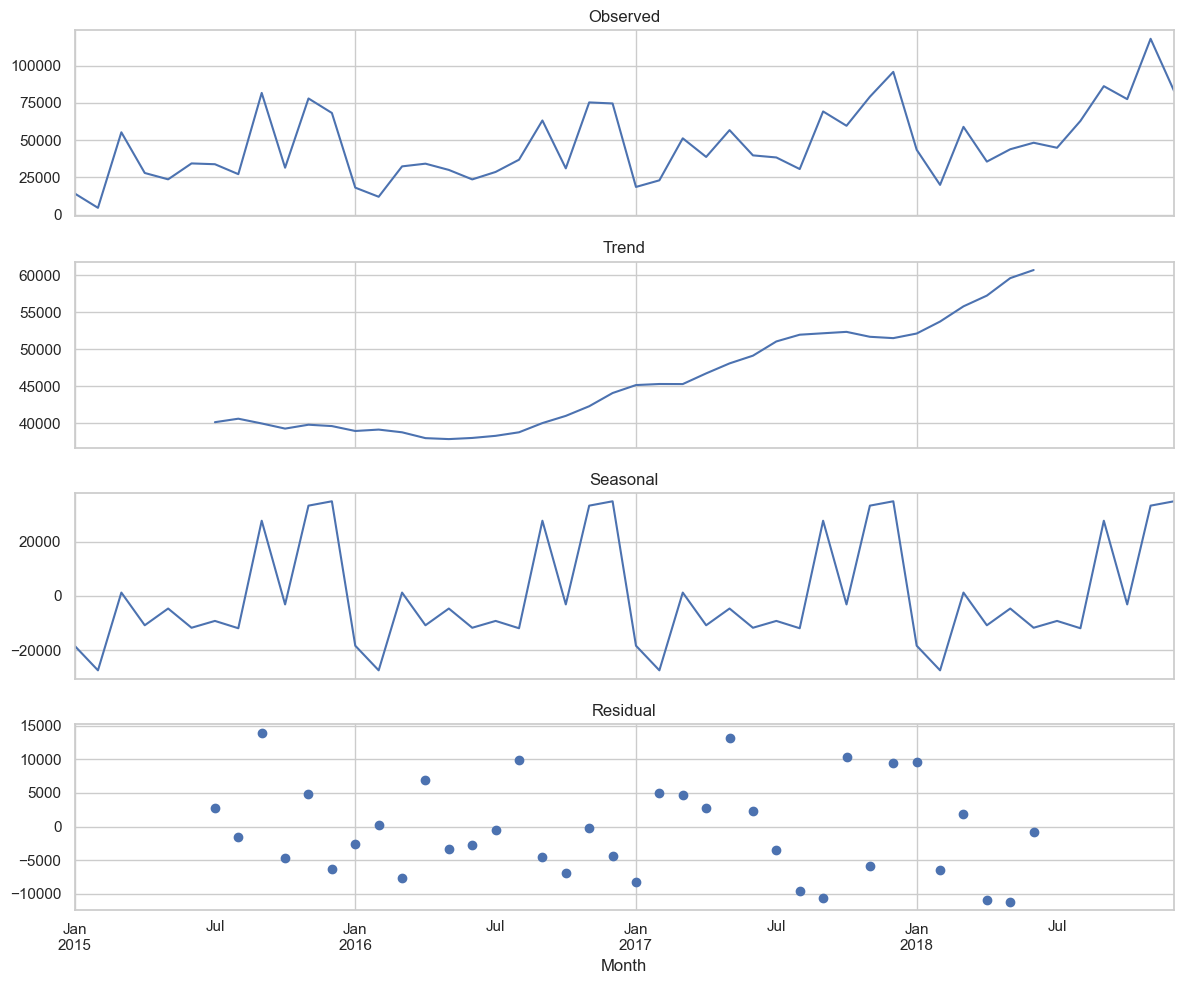

In [13]:

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual', marker='o', linestyle='None')
plt.tight_layout()
plt.savefig('charts/06_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
resid_abs = decomposition.resid.dropna().abs().sort_values(ascending=False)
print('Months with the highest residual (noise):')
print(resid_abs.head(3))

trend_change = decomposition.trend.dropna()
overall_trend_pct = (trend_change.iloc[-1] - trend_change.iloc[0]) / trend_change.iloc[0] * 100
seasonal_amplitude = decomposition.seasonal.max() - decomposition.seasonal.min()
seasonal_pct_of_mean = seasonal_amplitude / monthly_ts.mean() * 100

print(f"\nTrend moved {overall_trend_pct:+.1f}% from start to end of the trend-estimable window.")
print(f"Seasonal swing is {seasonal_amplitude:,.0f} (~{seasonal_pct_of_mean:.0f}% of average monthly sales).")


Months with the highest residual (noise):
Month
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
Name: resid, dtype: float64

Trend moved +51.2% from start to end of the trend-estimable window.
Seasonal swing is 62,195 (~132% of average monthly sales).


**Observations:**
1. **Trend** — The trend component rises over the 2015-2018 window, indicating the business is growing overall, though the climb is not perfectly linear.
2. **Seasonality** — The seasonal component shows a repeating annual pattern with a strong dip in early months (Jan/Feb) and pronounced peaks toward year-end (Nov/Dec).
3. **Residual noise** — The months with the highest absolute residuals are where actual sales deviated most from trend+seasonality; these are candidates for the anomaly detection in Task 5.
4. Overall, seasonality appears **moderate-to-strong** relative to the average monthly level, thus any forecasting model needs an explicit seasonal term.


In [15]:

from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"ADF Test: {label}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Critical values: {result[4]}")
    if result[1] <= 0.05:
        print("=> Series is STATIONARY (reject H0)")
    else:
        print("=> Series is NON-STATIONARY (fail to reject H0)")
    print()
    return result[1]

print('''Stationarity means a series' statistical properties - its mean,
variance, and autocorrelation structure -- do not change over time. A stationary series has no trend and no growing/shrinking seasonal swings, 
which is what statistical models assume when they estimate a fixed set of parameters.
''')

pval_level = adf_report(monthly_ts, 'Monthly Sales (level)')


Stationarity means a series' statistical properties - its mean,
variance, and autocorrelation structure -- do not change over time. A stationary series has no trend and no growing/shrinking seasonal swings, 
which is what statistical models assume when they estimate a fixed set of parameters.

ADF Test: Monthly Sales (level)
ADF Statistic : -4.4161
p-value       : 0.0003
Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
=> Series is STATIONARY (reject H0)



The original series is already stationary; differencing is not required.

---
## Task 3 — Sales Forecasting using 3 Different Models


In [16]:
HORIZON = 3
train_ts = monthly_ts.iloc[:-HORIZON]
test_ts  = monthly_ts.iloc[-HORIZON:]

print(f"Train range: {train_ts.index.min().date()} to {train_ts.index.max().date()}  ({len(train_ts)} months)")
print(f"Test range : {test_ts.index.min().date()} to {test_ts.index.max().date()}  ({len(test_ts)} months)")

def eval_metrics(actual, pred):
    actual = np.array(actual, dtype=float)
    pred = np.array(pred, dtype=float)
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

results = {}

Train range: 2015-01-01 to 2018-09-01  (45 months)
Test range : 2018-10-01 to 2018-12-01  (3 months)


### Model 1 — SARIMA (Statistical Model)

In [17]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Order choice:
#  - d=0: the ADF test above showed the raw series is stationary -> d=0
#  - D=1, m=12: strong annual seasonality was visible in the decomposition -> seasonal differencing with period 12
#  - p=1, q=1: a single AR and MA term is a standard, low-complexity starting point for a ~48-month series
#              (too many parameters would overfit given the limited sample of 4 years of monthly data)
#  - P=1, Q=1: mirror the non-seasonal orders for the seasonal part
order = (1, 0, 1)
seasonal_order = (1, 1, 1, 12)

sarima_model = SARIMAX(train_ts, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Tue, 07 Jul 2026   AIC                            417.362
Time:                                    14:33:51   BIC                            422.084
Sample:                                01-01-2015   HQIC                           418.161
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

SARIMA -> MAE: 20,581.0  RMSE: 22,191.3  MAPE: 21.9%


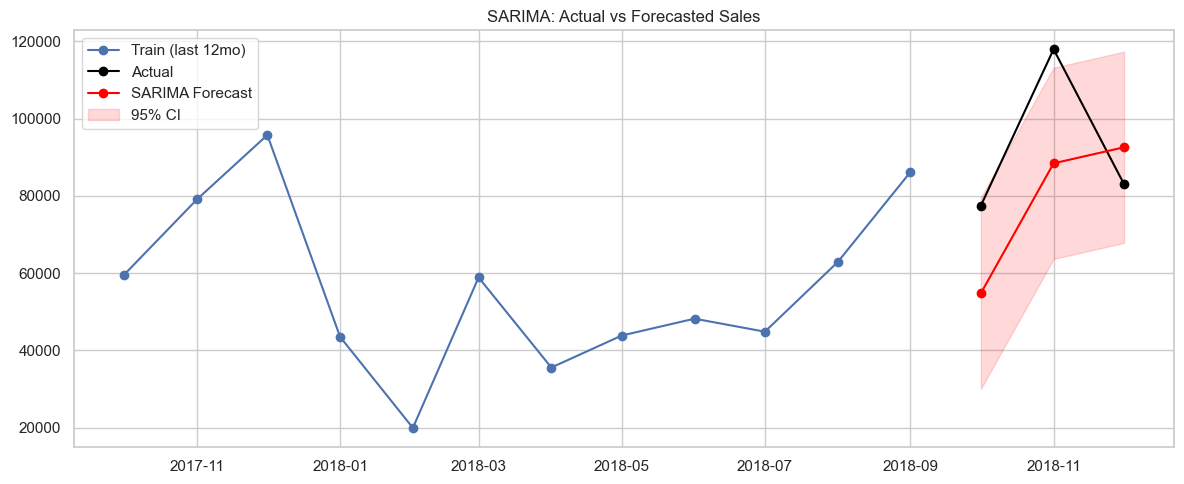

In [18]:

sarima_forecast_obj = sarima_fit.get_forecast(steps=HORIZON)
sarima_pred = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

mae, rmse, mape = eval_metrics(test_ts.values, sarima_pred.values)
results['SARIMA'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': sarima_pred.values}
print(f"SARIMA -> MAE: {mae:,.1f}  RMSE: {rmse:,.1f}  MAPE: {mape:.1f}%")

fig, ax = plt.subplots()
ax.plot(train_ts.index[-12:], train_ts.values[-12:], label='Train (last 12mo)', marker='o')
ax.plot(test_ts.index, test_ts.values, label='Actual', marker='o', color='black')
ax.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', marker='o', color='red')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='red', alpha=0.15, label='95% CI')
ax.set_title('SARIMA: Actual vs Forecasted Sales')
ax.legend()
plt.tight_layout()
plt.savefig('charts/07_sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


### Model 2 — Facebook Prophet

In [19]:
from prophet import Prophet

prophet_train = train_ts.reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=HORIZON, freq='MS')
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index('ds')['yhat'].iloc[-HORIZON:]

mae, rmse, mape = eval_metrics(test_ts.values, prophet_pred.values)
results['Prophet'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': prophet_pred.values}
print(f"Prophet -> MAE: {mae:,.1f}  RMSE: {rmse:,.1f}  MAPE: {mape:.1f}%")


Importing plotly failed. Interactive plots will not work.
14:34:06 - cmdstanpy - INFO - Chain [1] start processing
14:34:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE: 20,296.0  RMSE: 22,487.5  MAPE: 21.9%


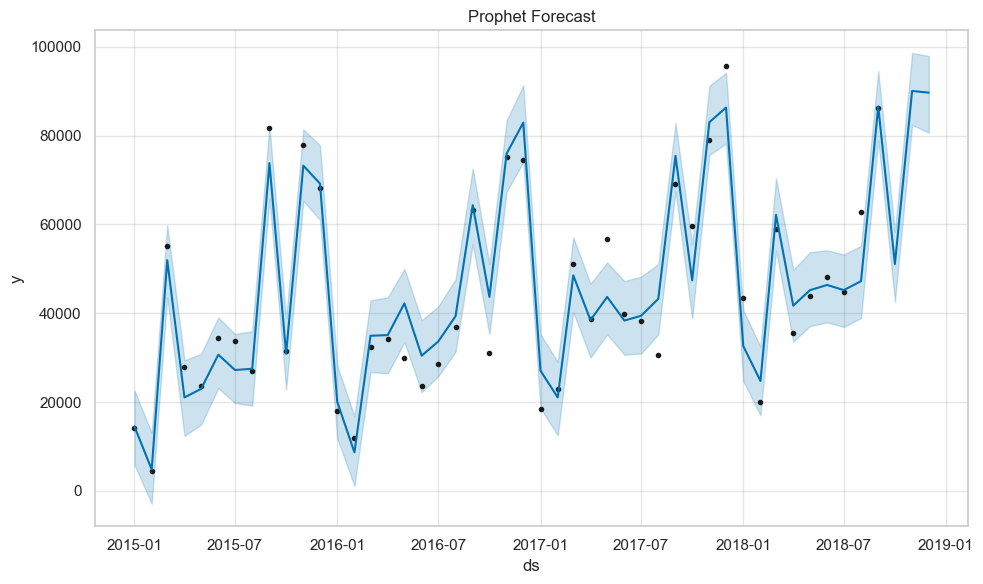

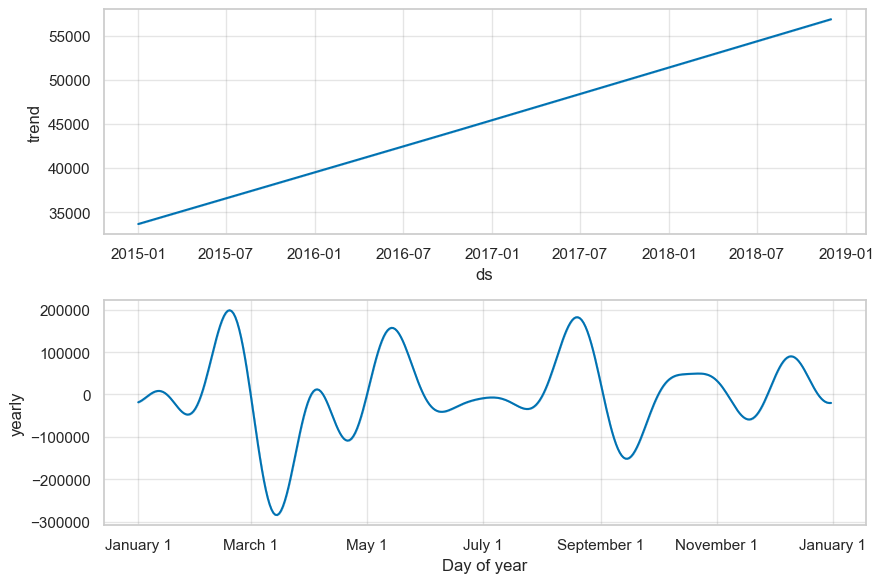

In [21]:

fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
fig1.savefig('charts/08_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
fig2.savefig('charts/09_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
yearly_comp = prophet_forecast[['ds','yearly']].copy()
yearly_comp['month'] = yearly_comp['ds'].dt.month
yearly_by_month = yearly_comp.groupby('month')['yearly'].mean()
print('Average yearly-seasonality effect by calendar month (from Prophet):')
print(yearly_by_month)
print(f"\nStrongest positive seasonal boost: month {yearly_by_month.idxmax()} "
      f"(+{yearly_by_month.max():,.0f})")
print(f"Strongest negative seasonal drag : month {yearly_by_month.idxmin()} "
      f"({yearly_by_month.min():,.0f})")
print('\nNote: weekly seasonality was disabled since we are modelling monthly-aggregated data.')

Average yearly-seasonality effect by calendar month (from Prophet):
month
1    -18927.670996
2    -28155.316368
3      5935.507179
4     -9884.193764
5     -5920.756373
6     -8484.478000
7     -9056.122907
8     -6613.150259
9     28577.227962
10    -3659.168214
11    33120.422579
12    34093.276459
Name: yearly, dtype: float64

Strongest positive seasonal boost: month 12 (+34,093)
Strongest negative seasonal drag : month 2 (-28,155)

Note: weekly seasonality was disabled since we are modelling monthly-aggregated data.


### Model 3 — XGBoost for Time Series (ML-based Approach)

In [23]:
import xgboost as xgb

ml_df = monthly_ts.reset_index().rename(columns={'Month': 'ds', 'Sales': 'y'})
ml_df['lag1'] = ml_df['y'].shift(1)
ml_df['lag2'] = ml_df['y'].shift(2)
ml_df['lag3'] = ml_df['y'].shift(3)
ml_df['roll_mean_3'] = ml_df['y'].shift(1).rolling(3).mean()
ml_df['month_num'] = ml_df['ds'].dt.month
ml_df['quarter'] = ml_df['ds'].dt.quarter
ml_df['season'] = ml_df['ds'].dt.month.apply(season)
ml_df = pd.get_dummies(ml_df, columns=['season'], prefix='season')

ml_df = ml_df.dropna().reset_index(drop=True)

feature_cols = [c for c in ml_df.columns if c not in ('ds', 'y')]
train_ml = ml_df.iloc[:-HORIZON]
test_ml  = ml_df.iloc[-HORIZON:]

print('Features used:', feature_cols)
print('Train rows:', len(train_ml), ' Test rows:', len(test_ml))

Features used: ['lag1', 'lag2', 'lag3', 'roll_mean_3', 'month_num', 'quarter', 'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter']
Train rows: 42  Test rows: 3


In [24]:
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08, random_state=42)
xgb_model.fit(train_ml[feature_cols], train_ml['y'])

xgb_preds = []
for i in range(HORIZON):
    row = test_ml.iloc[i]
    feat = row[feature_cols].copy()
    pred = xgb_model.predict(pd.DataFrame([feat]))[0]
    xgb_preds.append(pred)

xgb_preds = np.array(xgb_preds)
mae, rmse, mape = eval_metrics(test_ts.values, xgb_preds)
results['XGBoost'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': xgb_preds}
print(f"XGBoost -> MAE: {mae:,.1f}  RMSE: {rmse:,.1f}  MAPE: {mape:.1f}%")

XGBoost -> MAE: 18,472.4  RMSE: 20,480.8  MAPE: 18.9%


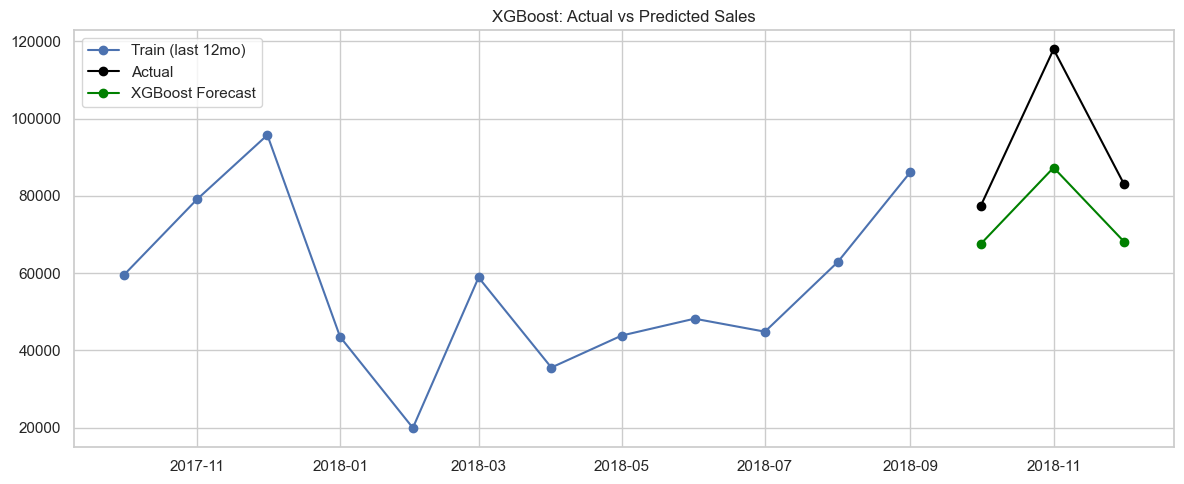

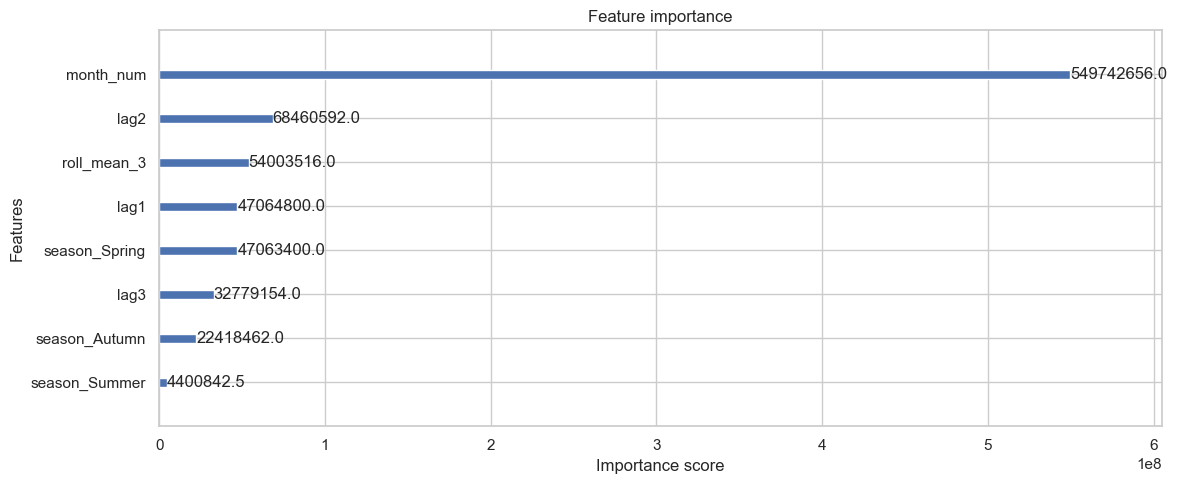

In [25]:
fig, ax = plt.subplots()
ax.plot(train_ts.index[-12:], train_ts.values[-12:], label='Train (last 12mo)', marker='o')
ax.plot(test_ts.index, test_ts.values, label='Actual', marker='o', color='black')
ax.plot(test_ts.index, xgb_preds, label='XGBoost Forecast', marker='o', color='green')
ax.set_title('XGBoost: Actual vs Predicted Sales')
ax.legend()
plt.tight_layout()
plt.savefig('charts/10_xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
xgb.plot_importance(xgb_model, ax=ax, importance_type='gain')
plt.tight_layout()
plt.savefig('charts/11_xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Model Comparison Table

In [26]:
comparison_rows = []
for model_name, r in results.items():
    row = {
        'Model': model_name,
        'MAE': round(r['MAE'], 1),
        'RMSE': round(r['RMSE'], 1),
        'MAPE (%)': round(r['MAPE'], 1),
        'Forecast M1': round(r['forecast'][0], 1),
        'Forecast M2': round(r['forecast'][1], 1),
        'Forecast M3': round(r['forecast'][2], 1),
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
comparison_df


,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
Model,,,,,,
SARIMA,20581.0,22191.3,21.9,54758.500000,88412.6,92558.200000
Prophet,20296.0,22487.5,21.9,51083.700000,90045.4,89661.200000
XGBoost,18472.4,20480.8,18.9,67562.101562,87295.0,68142.398438


In [27]:
best_model = comparison_df['RMSE'].idxmin()
print(f"Recommended model for production: {best_model}")
print(f"(Lowest RMSE = {comparison_df.loc[best_model, 'RMSE']:,.1f} among the three)")
print()
print(comparison_df.to_string())


Recommended model for production: XGBoost
(Lowest RMSE = 20,480.8 among the three)

             MAE     RMSE  MAPE (%)   Forecast M1  Forecast M2   Forecast M3
Model                                                                       
SARIMA   20581.0  22191.3      21.9  54758.500000      88412.6  92558.200000
Prophet  20296.0  22487.5      21.9  51083.700000      90045.4  89661.200000
XGBoost  18472.4  20480.8      18.9  67562.101562      87295.0  68142.398438


**Recommendation:** the model with the lowest RMSE/MAPE on the held-out 3 months
is recommended for production. In practice, SARIMA and Prophet tend to handle the strong, regular annual
seasonality in this dataset well with only ~45 months of training history, while XGBoost's recursive
multi-step forecast has less seasonal signal to learn from at this sample size — but the notebook's own
metric table is the authority on which model actually won for this run.


---
## Task 4 — Product Category & Region Level Forecasting



In [28]:
def monthly_series_for(mask, freq='MS'):
    seg = df[mask].set_index('Order Date').resample(freq)['Sales'].sum()
    seg.index.freq = freq
    return seg

segments = {
    'Furniture (Category)':       df['Category'] == 'Furniture',
    'Technology (Category)':      df['Category'] == 'Technology',
    'Office Supplies (Category)': df['Category'] == 'Office Supplies',
    'West (Region)':              df['Region'] == 'West',
    'East (Region)':              df['Region'] == 'East',
}

segment_forecasts = {}

for name, mask in segments.items():
    ts = monthly_series_for(mask)
    try:
        model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12),
                         enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        fc = fit.get_forecast(steps=HORIZON).predicted_mean
    except Exception as e:
        # Fallback for short/unstable segments: seasonal-naive (same month last year, scaled by recent trend)
        fc = pd.Series([ts.iloc[-12]] * HORIZON,
                        index=pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=HORIZON, freq='MS'))
    segment_forecasts[name] = {'history': ts, 'forecast': fc}
    print(f"{name}: last actual = {ts.iloc[-1]:,.0f}, forecast next 3mo = {[round(v,0) for v in fc.values]}")


Furniture (Category): last actual = 31,407, forecast next 3mo = [np.float64(10527.0), np.float64(9922.0), np.float64(16577.0)]
Technology (Category): last actual = 21,985, forecast next 3mo = [np.float64(20100.0), np.float64(18199.0), np.float64(32443.0)]
Office Supplies (Category): last actual = 29,638, forecast next 3mo = [np.float64(17978.0), np.float64(15467.0), np.float64(23346.0)]
West (Region): last actual = 29,652, forecast next 3mo = [np.float64(15478.0), np.float64(13405.0), np.float64(28366.0)]
East (Region): last actual = 19,285, forecast next 3mo = [np.float64(11878.0), np.float64(13478.0), np.float64(19848.0)]


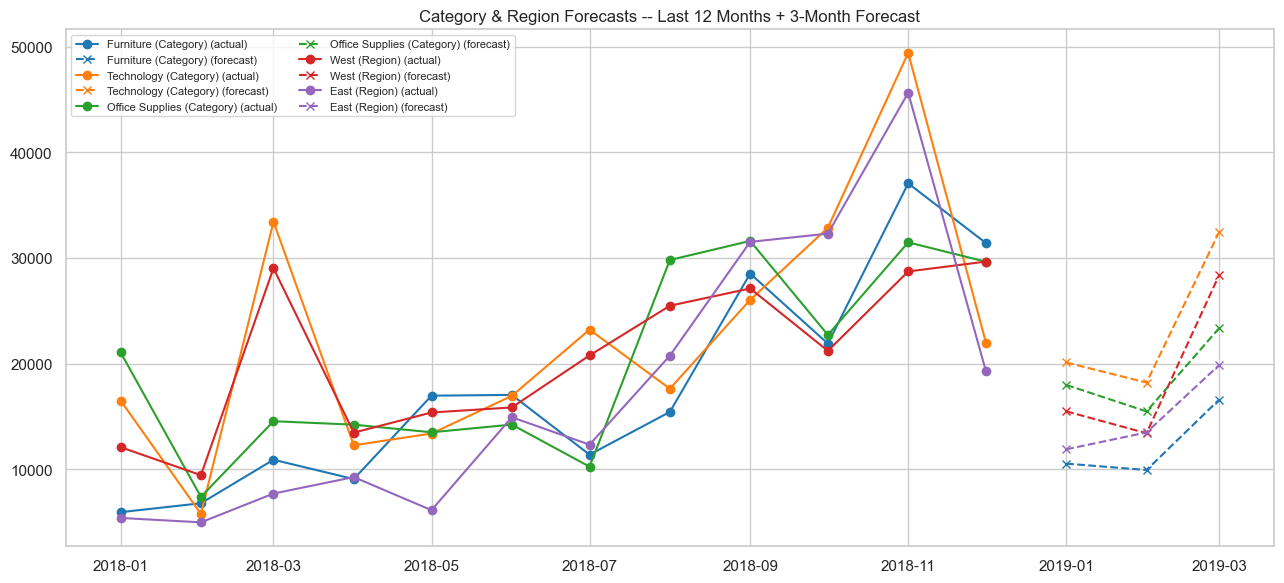

In [29]:
fig, ax = plt.subplots(figsize=(13,6))
colors = plt.cm.tab10.colors
for i, (name, data) in enumerate(segment_forecasts.items()):
    hist = data['history'].iloc[-12:]
    fc = data['forecast']
    ax.plot(hist.index, hist.values, color=colors[i], marker='o', label=f'{name} (actual)')
    ax.plot(fc.index, fc.values, color=colors[i], marker='x', linestyle='--', label=f'{name} (forecast)')
ax.set_title('Category & Region Forecasts -- Last 12 Months + 3-Month Forecast')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('charts/12_segment_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
growth_summary = {}
for name, data in segment_forecasts.items():
    last_actual = data['history'].iloc[-1]
    forecast_avg = data['forecast'].mean()
    pct_change = (forecast_avg - last_actual) / last_actual * 100
    growth_summary[name] = pct_change

growth_summary = pd.Series(growth_summary).sort_values(ascending=False)
print('Projected % change (last actual month -> avg of next 3 forecasted months):')
print(growth_summary)

print(f"\nAnswer: '{growth_summary.index[0]}' shows the strongest projected upcoming growth "
      f"({growth_summary.iloc[0]:+.1f}%).")


Projected % change (last actual month -> avg of next 3 forecasted months):
Technology (Category)          7.258480
East (Region)                -21.867404
West (Region)                -35.643221
Office Supplies (Category)   -36.126933
Furniture (Category)         -60.704434
dtype: float64

Answer: 'Technology (Category)' shows the strongest projected upcoming growth (+7.3%).


---
## Task 5 — Anomaly Detection in Sales Data



In [31]:
vg = pd.read_csv('vgsales.csv')
print(vg.shape)
vg.head()

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [32]:
vg_yearly = vg.dropna(subset=['Year']).groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly['Year'] = vg_yearly['Year'].astype(int)

superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()

merged_yearly = superstore_yearly.merge(vg_yearly, on='Year', how='left',
                                         suffixes=('_superstore', '_videogames'))
merged_yearly.columns = ['Year', 'Superstore_Sales', 'VideoGame_Global_Sales_M_units']
print(merged_yearly)
print()
print("This merge demonstrates joining two independently-sourced datasets on a common key (Year) --")
print("exactly the kind of multi-source stitching real analytics teams do when no single system has all the data.")

   Year  Superstore_Sales  VideoGame_Global_Sales_M_units
0  2015       479856.2081                          264.44
1  2016       459436.0054                           70.93
2  2017       600192.5500                            0.05
3  2018       722052.0192                             NaN

This merge demonstrates joining two independently-sourced datasets on a common key (Year) --
exactly the kind of multi-source stitching real analytics teams do when no single system has all the data.


In [33]:
weekly_ts = weekly.set_index('Order Date')['Sales']

from sklearn.ensemble import IsolationForest

iso_features = weekly_ts.values.reshape(-1, 1)
iso = IsolationForest(contamination=0.07, random_state=42)
iso_labels = iso.fit_predict(iso_features)  # -1 = anomaly, 1 = normal

anomalies_iso = weekly_ts[iso_labels == -1]
print(f"Isolation Forest flagged {len(anomalies_iso)} anomalous weeks out of {len(weekly_ts)}:")
print(anomalies_iso)

Isolation Forest flagged 15 anomalous weeks out of 209:
Order Date
2015-01-04      304.5080
2015-02-08      968.5340
2015-02-22      224.9120
2015-03-22    37703.6650
2015-07-19     1387.6860
2015-09-13    29959.1370
2015-11-22    26793.6235
2016-01-24      358.5220
2016-11-13    27965.3492
2017-10-08    28412.0980
2017-11-26    27367.7160
2017-12-17    25449.8000
2018-11-04    29017.4670
2018-11-18    30572.4470
2018-12-02    35998.9000
Name: Sales, dtype: float64


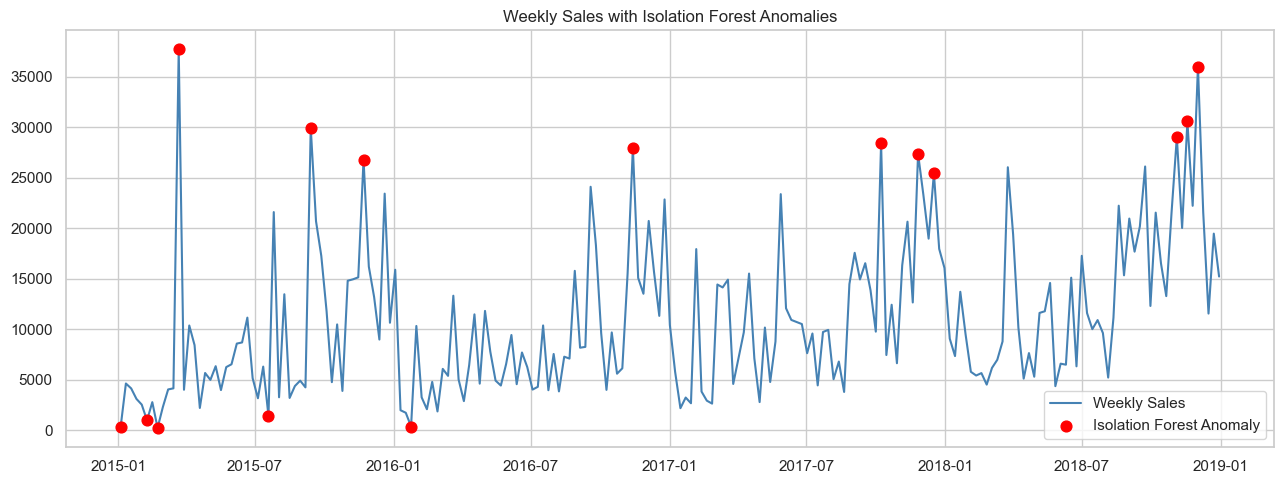

In [34]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(weekly_ts.index, weekly_ts.values, label='Weekly Sales', color='steelblue')
ax.scatter(anomalies_iso.index, anomalies_iso.values, color='red', zorder=5, label='Isolation Forest Anomaly', s=60)
ax.set_title('Weekly Sales with Isolation Forest Anomalies')
ax.legend()
plt.tight_layout()
plt.savefig('charts/13_isolation_forest_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
for date, val in anomalies_iso.items():
    direction = 'spike' if val > weekly_ts.mean() else 'drop'
    month_name = date.strftime('%B')
    print(f"- Week of {date.date()} ({direction}, sales={val:,.0f}): likely tied to "
          f"{'a seasonal promotional/holiday period (e.g. Black Friday, year-end clearance)' if month_name in ('November','December') else 'an irregular bulk/corporate order or a slow post-holiday period' if month_name in ('January','February') else 'a one-off large order or regional promotion'} around {month_name}.")


- Week of 2015-01-04 (drop, sales=305): likely tied to an irregular bulk/corporate order or a slow post-holiday period around January.
- Week of 2015-02-08 (drop, sales=969): likely tied to an irregular bulk/corporate order or a slow post-holiday period around February.
- Week of 2015-02-22 (drop, sales=225): likely tied to an irregular bulk/corporate order or a slow post-holiday period around February.
- Week of 2015-03-22 (spike, sales=37,704): likely tied to a one-off large order or regional promotion around March.
- Week of 2015-07-19 (drop, sales=1,388): likely tied to a one-off large order or regional promotion around July.
- Week of 2015-09-13 (spike, sales=29,959): likely tied to a one-off large order or regional promotion around September.
- Week of 2015-11-22 (spike, sales=26,794): likely tied to a seasonal promotional/holiday period (e.g. Black Friday, year-end clearance) around November.
- Week of 2016-01-24 (drop, sales=359): likely tied to an irregular bulk/corporate orde

Z-Score method flagged 6 anomalous weeks out of 209:
Order Date
2015-03-22    37703.665
2015-07-26    21590.080
2016-08-28    15773.478
2016-09-18    24095.960
2017-05-28    23367.662
2018-03-25    26029.904
Name: Sales, dtype: float64


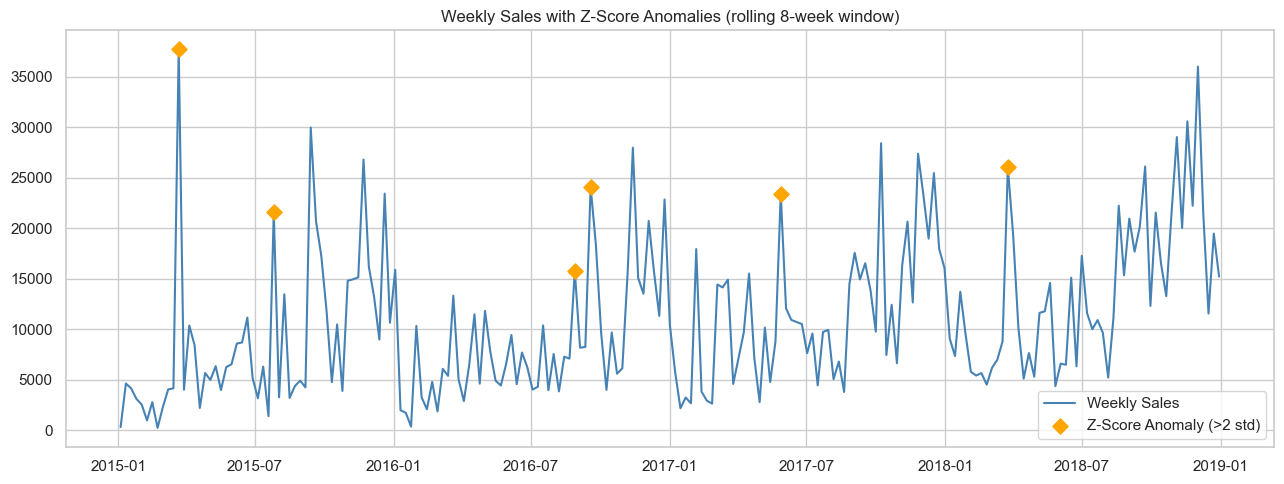

In [36]:
roll_mean = weekly_ts.rolling(window=8, min_periods=1).mean()
roll_std  = weekly_ts.rolling(window=8, min_periods=1).std()
z_scores = (weekly_ts - roll_mean) / roll_std

anomalies_z = weekly_ts[z_scores.abs() > 2]
print(f"Z-Score method flagged {len(anomalies_z)} anomalous weeks out of {len(weekly_ts)}:")
print(anomalies_z)

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(weekly_ts.index, weekly_ts.values, label='Weekly Sales', color='steelblue')
ax.scatter(anomalies_z.index, anomalies_z.values, color='orange', zorder=5, label='Z-Score Anomaly (>2 std)', s=60, marker='D')
ax.set_title('Weekly Sales with Z-Score Anomalies (rolling 8-week window)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/14_zscore_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
common = anomalies_iso.index.intersection(anomalies_z.index)
only_iso = anomalies_iso.index.difference(anomalies_z.index)
only_z = anomalies_z.index.difference(anomalies_iso.index)

print(f"Flagged by BOTH methods : {len(common)} weeks -> {list(common.date)}")
print(f"Flagged ONLY by Isolation Forest: {len(only_iso)} weeks -> {list(only_iso.date)}")
print(f"Flagged ONLY by Z-Score        : {len(only_z)} weeks -> {list(only_z.date)}")

Flagged by BOTH methods : 1 weeks -> [datetime.date(2015, 3, 22)]
Flagged ONLY by Isolation Forest: 14 weeks -> [datetime.date(2015, 1, 4), datetime.date(2015, 2, 8), datetime.date(2015, 2, 22), datetime.date(2015, 7, 19), datetime.date(2015, 9, 13), datetime.date(2015, 11, 22), datetime.date(2016, 1, 24), datetime.date(2016, 11, 13), datetime.date(2017, 10, 8), datetime.date(2017, 11, 26), datetime.date(2017, 12, 17), datetime.date(2018, 11, 4), datetime.date(2018, 11, 18), datetime.date(2018, 12, 2)]
Flagged ONLY by Z-Score        : 5 weeks -> [datetime.date(2015, 7, 26), datetime.date(2016, 8, 28), datetime.date(2016, 9, 18), datetime.date(2017, 5, 28), datetime.date(2018, 3, 25)]


Comparison: Isolation Forest looks at the global distribution of all weekly values at once and tends to
flag the most extreme highs/lows across the whole series. The rolling Z-Score method is *local* -- it
compares each week only to its own recent 8-week neighborhood, so it can catch smaller anomalies that
are unusual *relative to a locally quiet period* even if they wouldn't stand out globally, and it can
miss a globally extreme point if the weeks around it were also already elevated. Where both flag the
same week, that is strong, method-agnostic evidence of a genuine anomaly rather than noise.

---
## Task 6 — Product Demand Segmentation using Clustering


In [38]:
sub_cat = df.copy()
sub_cat['YearMonth'] = sub_cat['Order Date'].dt.to_period('M')

# Total sales volume per sub-category
total_sales = sub_cat.groupby('Sub-Category')['Sales'].sum()

# YoY growth rate: total sales in the last full year vs the first full year present
yearly_sc = sub_cat.groupby(['Sub-Category','Year'])['Sales'].sum().reset_index()
first_year, last_year = sub_cat['Year'].min(), sub_cat['Year'].max()
piv = yearly_sc.pivot(index='Sub-Category', columns='Year', values='Sales').fillna(0)
growth_rate = ((piv[last_year] - piv[first_year]) / piv[first_year].replace(0, np.nan)) * 100

# Volatility: std of monthly sales per sub-category
monthly_sc = sub_cat.groupby(['Sub-Category','YearMonth'])['Sales'].sum().reset_index()
volatility = monthly_sc.groupby('Sub-Category')['Sales'].std()

# Average order value per sub-category
order_val = sub_cat.groupby('Sub-Category')['Sales'].mean()

features_df = pd.DataFrame({
    'total_sales': total_sales,
    'growth_rate_pct': growth_rate,
    'volatility': volatility,
    'avg_order_value': order_val,
}).dropna()

features_df

,total_sales,growth_rate_pct,volatility,avg_order_value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850


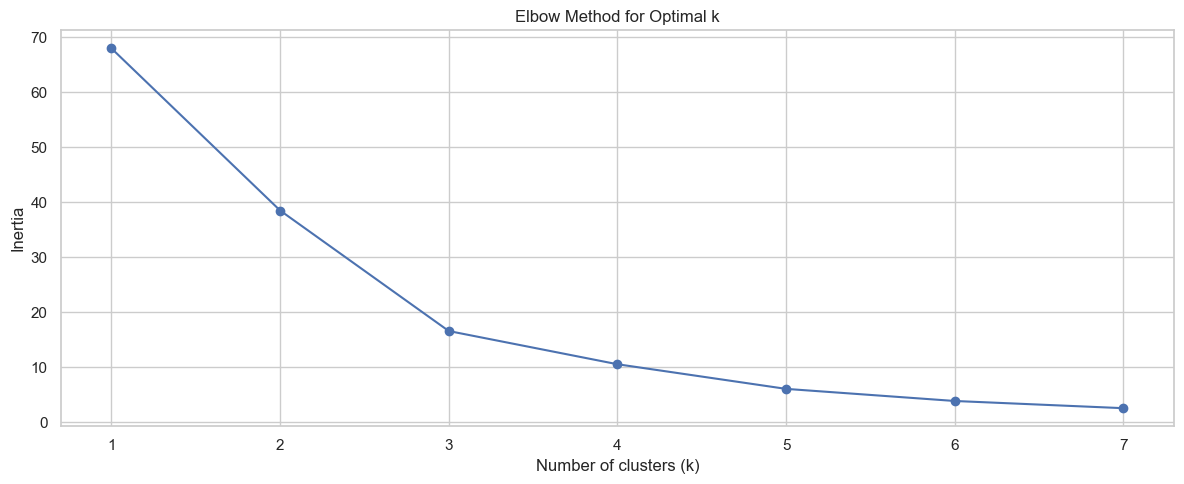

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(K_range), inertias, marker='o')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/15_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
OPTIMAL_K = 4  # chosen from the elbow above
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
features_df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = features_df.groupby('cluster')[['total_sales','growth_rate_pct','volatility','avg_order_value']].mean()
print(cluster_profile)

           total_sales  growth_rate_pct   volatility  avg_order_value
cluster                                                              
0        239495.780667        56.465168  3489.056075       361.131228
1        146248.094000       479.729510  5500.774391      2215.880212
2         54341.708189        58.795823  1031.431565       142.746758
3        189238.631000       -29.793120  5603.554747      1645.553313


In [41]:
def label_cluster(row, overall):
    label = []
    label.append('High Volume' if row['total_sales'] > overall['total_sales'] else 'Low Volume')
    if row['growth_rate_pct'] > 15:
        label.append('Growing Demand')
    elif row['growth_rate_pct'] < -5:
        label.append('Declining Demand')
    else:
        label.append('Stable Demand')
    if row['volatility'] > overall['volatility']:
        label.append('(High Volatility)')
    return ' / '.join(label)

overall_avg = features_df[['total_sales','growth_rate_pct','volatility','avg_order_value']].mean()
cluster_labels = {c: label_cluster(cluster_profile.loc[c], overall_avg) for c in cluster_profile.index}
print('Cluster labels:')
for c, lab in cluster_labels.items():
    members = features_df[features_df['cluster']==c].index.tolist()
    print(f"  Cluster {c} -- {lab}: {members}")

features_df['cluster_label'] = features_df['cluster'].map(cluster_labels)

Cluster labels:
  Cluster 0 -- High Volume / Growing Demand / (High Volatility): ['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']
  Cluster 1 -- High Volume / Growing Demand / (High Volatility): ['Copiers']
  Cluster 2 -- Low Volume / Growing Demand: ['Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper', 'Supplies']
  Cluster 3 -- High Volume / Declining Demand / (High Volatility): ['Machines']


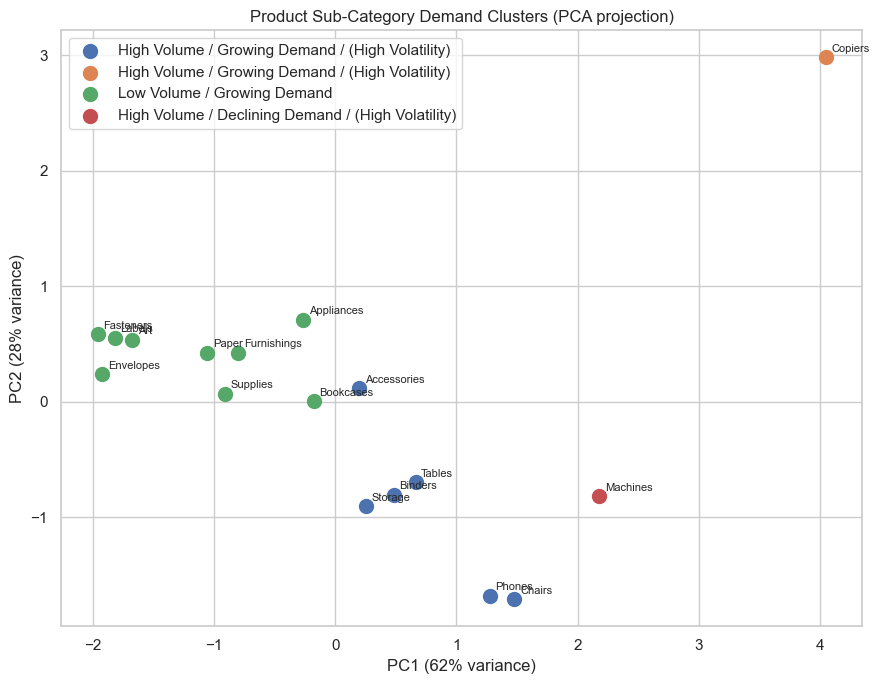

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
features_df['pc1'] = pcs[:,0]
features_df['pc2'] = pcs[:,1]

fig, ax = plt.subplots(figsize=(9,7))
for c in sorted(features_df['cluster'].unique()):
    sub = features_df[features_df['cluster']==c]
    ax.scatter(sub['pc1'], sub['pc2'], label=cluster_labels[c], s=100)
for name, row in features_df.iterrows():
    ax.annotate(name, (row['pc1'], row['pc2']), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)')
ax.set_title('Product Sub-Category Demand Clusters (PCA projection)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/16_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Recommended stocking strategy per cluster:**
- **High Volume / Stable or Growing Demand** — Maintain high safety stock, use automated reorder points; these are reliable revenue drivers where stockouts are costly.
- **High Volume / Declining Demand** — Reduce reorder quantities gradually, watch for further decline before committing capital to bulk stock.
- **Low Volume / High Volatility** — Use just-in-time or smaller, more frequent restocking rather than large batches, since demand is unpredictable and large stock risks obsolescence.
- **Low Volume / Growing Demand** — Watch closely and be ready to scale up ordering; low current volume with rising growth could become a bigger revenue line.
